In [57]:
res = {}
rnode = {}
llist = {}
with open("./../llama_graph_times.txt", "r") as f:
    for l in f:
        if "Compute forward" in l:
            nm = l[l.find("[")+1:l.find("]")]
            tm = int(l[l.find("(")+1:l.find(")")])
            nd = int(l.split(",")[0].split(" ")[-1])
            if nd in rnode:
                rnode[nd] += tm
            else:
                rnode[nd] = tm
            if not nm in res:
                print(nm, tm)
                res[nm] = tm
                llist[nm] = {nd}
            else:
                res[nm] += tm
                llist[nm].add(nd)

GGML_OP_RMS_NORM 2672
GGML_OP_MUL 586
GGML_OP_MUL_MAT 90192
GGML_OP_RESHAPE 1
GGML_OP_ROPE 1936
GGML_OP_VIEW 2
GGML_OP_CPY 1578
GGML_OP_TRANSPOSE 2
GGML_OP_PERMUTE 0
GGML_OP_SOFT_MAX 8031
GGML_OP_CONT 1028
GGML_OP_ADD 1059
GGML_OP_UNARY 2503
GGML_OP_GET_ROWS 1


In [58]:
for k in res.keys():
    res[k] /= 1000000
for k in rnode.keys():
    rnode[k] /= 1000000

In [59]:
print(res)

{'GGML_OP_RMS_NORM': 0.369323, 'GGML_OP_MUL': 0.600533, 'GGML_OP_MUL_MAT': 144.456491, 'GGML_OP_RESHAPE': 0.002539, 'GGML_OP_ROPE': 0.330115, 'GGML_OP_VIEW': 0.002245, 'GGML_OP_CPY': 0.761838, 'GGML_OP_TRANSPOSE': 0.000416, 'GGML_OP_PERMUTE': 0.00138, 'GGML_OP_SOFT_MAX': 1.066445, 'GGML_OP_CONT': 0.152009, 'GGML_OP_ADD': 0.268793, 'GGML_OP_UNARY': 0.311674, 'GGML_OP_GET_ROWS': 0.000244}


In [60]:
print("Matrix multiplications layer count:",len(llist["GGML_OP_MUL_MAT"]))
print("Layers:",llist["GGML_OP_MUL_MAT"])

Matrix multiplications layer count: 542
Layers: {2, 3, 5, 6, 8, 9, 17, 18, 19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 34, 35, 37, 38, 40, 41, 49, 50, 51, 52, 54, 55, 58, 59, 60, 61, 62, 63, 66, 67, 69, 70, 72, 73, 81, 82, 83, 84, 86, 87, 90, 91, 92, 93, 94, 95, 98, 99, 101, 102, 104, 105, 113, 114, 115, 116, 118, 119, 122, 123, 124, 125, 126, 127, 130, 131, 133, 134, 136, 137, 145, 146, 147, 148, 150, 151, 154, 155, 156, 157, 158, 159, 162, 163, 165, 166, 168, 169, 177, 178, 179, 180, 182, 183, 186, 187, 188, 189, 190, 191, 194, 195, 197, 198, 200, 201, 209, 210, 211, 212, 214, 215, 218, 219, 220, 221, 222, 223, 226, 227, 229, 230, 232, 233, 241, 242, 243, 244, 246, 247, 250, 251, 252, 253, 254, 255, 258, 259, 261, 262, 264, 265, 273, 274, 275, 276, 278, 279, 282, 283, 284, 285, 286, 287, 290, 291, 293, 294, 296, 297, 305, 306, 307, 308, 310, 311, 314, 315, 316, 317, 318, 319, 322, 323, 325, 326, 328, 329, 337, 338, 339, 340, 342, 343, 346, 347, 348, 349, 350, 351, 354, 355, 357, 358, 360

In [61]:
vpr = []
for k in rnode:
    vpr.append((rnode[k], k))
vpr.sort()
vpr = vpr[::-1]
print(vpr)

[(1.407513, 766), (1.345242, 94), (1.336127, 574), (1.327959, 30), (1.322115, 286), (1.321694, 862), (1.318697, 190), (1.282736, 670), (1.280316, 478), (1.279509, 62), (1.276739, 926), (1.272816, 894), (1.263771, 382), (1.175582, 316), (1.158291, 826), (1.128991, 346), (1.11141, 314), (1.093064, 734), (1.05051, 798), (1.037904, 250), (1.02705, 126), (0.991163, 318), (0.988861, 794), (0.985945, 154), (0.979521, 730), (0.97663, 762), (0.97426, 732), (0.953326, 58), (0.952137, 764), (0.939414, 252), (0.932735, 796), (0.920603, 188), (0.915849, 858), (0.914687, 476), (0.913875, 538), (0.912824, 282), (0.912424, 828), (0.90835, 860), (0.90786, 284), (0.90611, 540), (0.905699, 700), (0.905156, 90), (0.901848, 218), (0.899842, 186), (0.898081, 830), (0.897882, 28), (0.897611, 380), (0.896235, 508), (0.895093, 890), (0.895077, 348), (0.894831, 922), (0.892768, 156), (0.891216, 92), (0.890367, 158), (0.889947, 26), (0.889793, 378), (0.888681, 254), (0.885723, 572), (0.880752, 122), (0.88072, 69

In [62]:
import matplotlib.pyplot as plt
import numpy as np

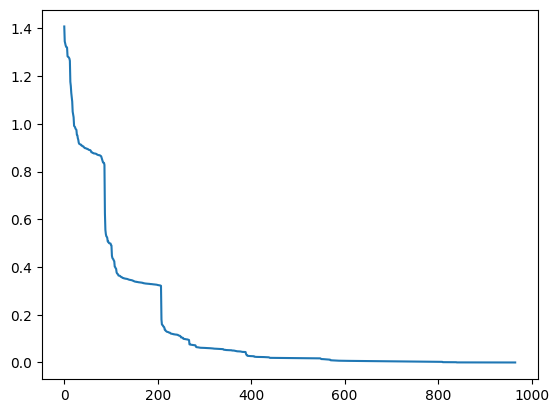

In [67]:
idx = np.array([x for x in range(len(vpr))])
Y = np.array([x[0] for x in vpr])
plt.plot(idx, Y)

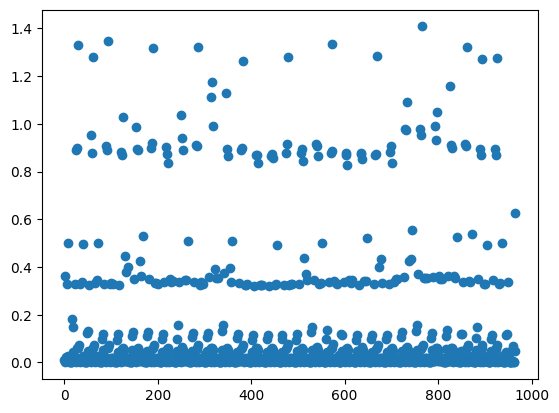

In [64]:
idx = np.array([x[1] for x in vpr])
Y = np.array([x[0] for x in vpr])
plt.scatter(idx, Y)